# Sales Performance Dashboard
## Indian FMCG — one dashboard to replace 4 Excel files

Business situation:
KiranaPlus distributes FMCG products across 15 Indian cities. The VP of Sales reviews performance every Monday morning and currently does it manually by looking at four separate Excel files. Your task: build one live dashboard that answers every question the VP has — by region, by SKU, by time period — so they never need to open Excel again. The dashboard must load in under 3 seconds and work on a laptop screen.

Questions the dashboard will answer:
- 01 Total revenue this month vs last month — show % change with a colour indicator (green/red).
- 02 Revenue by Indian state — rendered as an India map visual (mandatory).
- 03 Top 10 SKUs by revenue — bar chart, filterable by region and category.
- 04 Target vs actual performance — by zone (North / South / East / West).
- 05 Monthly revenue trend for the last 12 months — show seasonality clearly.
- 06 Revenue split by category — treemap or donut chart.
- 07 Products with 3 consecutive months of declining sales — flag them in a separate view.
- 08 KPI scorecard row at the top: Revenue, Units Sold, AOV, Return Rate — all with MoM delta.
- 09 Day-of-week sales pattern — which days sell most and least?
- 10 All slicers must be connected — changing one filters everything else simultaneously.

Deliverables:
- Published Power BI / Tableau dashboard With a live shareable link.
- .pbix or .twbx file on GitHub: Source dashboard file checked in.
- README insight paragraph. One paragraph: what the dashboard revealed that the raw data hid.  

URL of the dataset :
https://www.kaggle.com/datasets/abuhumzakhan/store-data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

In [2]:
df_raw=pd.read_csv("sales_data.csv")
df= df_raw.copy()   

# work on a copy; df_raw stays untouched

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Customer ID        100000 non-null  str    
 1   Customer Name      100000 non-null  str    
 2   Last Name          100000 non-null  str    
 3   Date of Birth      100000 non-null  str    
 4   Sales              100000 non-null  float64
 5   Year               100000 non-null  int64  
 6   Outlet Type        100000 non-null  str    
 7   City Type          100000 non-null  str    
 8   Category of Goods  100000 non-null  str    
 9   Region             100000 non-null  str    
 10  Country            100000 non-null  str    
 11  Segment            100000 non-null  str    
 12  Sales Date         100000 non-null  str    
 13  Order ID           100000 non-null  str    
 14  Order Date         100000 non-null  str    
 15  Ship Date          100000 non-null  str    
 16  Ship Mode     

### We will consider this file to achieve the project goal.

In [4]:
df.head()

,Customer ID,Customer Name,Last Name,Date of Birth,Sales,Year,Outlet Type,City Type,Category of Goods,Region,Country,Segment,Sales Date,Order ID,Order Date,Ship Date,Ship Mode,State,Postal Code,Product ID,Sub-Category,Product Name,Quantity,Discount,Profit
0,CUST000001,Curtis,Krause,1973-11-29,3344.69,2023,Large,Tier 1,Fast Food,East,India,Consumer,2023-03-11,ORD000001,2020-04-13,2020-04-18,Same Day,West Bengal,700001,PROD000001,Burgers,Burgers - 718,3,0.09,448.24
1,CUST000002,Jeremy,Foster,1987-08-30,37094.41,2022,Medium,Tier 2,Fast Food,East,India,Corporate,2023-09-09,ORD000002,2021-01-08,2021-01-11,Standard Class,Punjab,160001,PROD000002,Pizzas,Pizzas - 519,5,0.39,3134.34
2,CUST000003,Ariel,Mccann,1980-12-15,35501.08,2023,Large,Village,Electric Appliances,South,India,Consumer,2022-08-15,ORD000003,2020-08-11,2020-08-16,Second Class,Gujarat,380001,PROD000003,Fans,Fans - 395,6,0.07,8324.21
3,CUST000004,Colleen,Maynard,1989-05-23,8969.33,2021,Medium,Village,Dairy Products,East,India,Corporate,2021-01-23,ORD000004,2021-10-10,2021-10-16,First Class,West Bengal,700001,PROD000004,Milk,Milk - 798,4,0.18,1962.66
4,CUST000005,Gina,Holden,1957-12-31,35530.44,2021,Small,Village,Sessional Fruits & Vegetables,West,India,Consumer,2020-12-24,ORD000005,2019-01-22,2019-01-25,Standard Class,Delhi,110001,PROD000005,Tomatoes,Tomatoes - 442,4,0.27,2843.93


In [5]:
print(f"The shape is {df.shape[0]} rows by {df.shape[1]} columns.")

The shape is 100000 rows by 25 columns.


In [6]:
df = df.rename(columns={
    'Customer Name': 'Customer First Name',
    'Last Name': 'Customer Last Name',
    'Sub-Category': 'Product Sub Category'
})

In [7]:
# Clean column names (strip spaces, lowercase, underscores)
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace(r"[^\w]", "", regex=True)
)
print("Cleaned columns:", df.columns.tolist())

Cleaned columns: ['customer_id', 'customer_first_name', 'customer_last_name', 'date_of_birth', 'sales', 'year', 'outlet_type', 'city_type', 'category_of_goods', 'region', 'country', 'segment', 'sales_date', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'state', 'postal_code', 'product_id', 'product_sub_category', 'product_name', 'quantity', 'discount', 'profit']


In [8]:
# Column-wise missing 
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_%":    (df.isnull().mean() * 100).round(2),
}).sort_values("missing_%", ascending=False)

print("Columns with missing values:")
missing[missing["missing_count"] > 0]

Columns with missing values:


,missing_count,missing_%


Rows with 0 missing:   100000
Rows with 1 missing:   0
Rows with 2 missing:   0
Rows with 3+ missing:  0


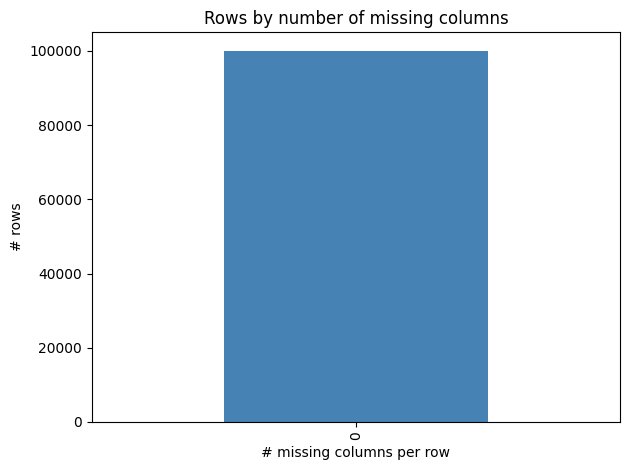

In [9]:
# Row-wise missing distribution 
row_missing = df.isnull().sum(axis=1)
print("Rows with 0 missing:  ", (row_missing == 0).sum())
print("Rows with 1 missing:  ", (row_missing == 1).sum())
print("Rows with 2 missing:  ", (row_missing == 2).sum())
print("Rows with 3+ missing: ", (row_missing >= 3).sum())

row_missing.value_counts().sort_index().plot(
    kind='bar', title='Rows by number of missing columns', color='steelblue'
)
plt.xlabel('# missing columns per row')
plt.ylabel('# rows')
plt.tight_layout()
plt.show()

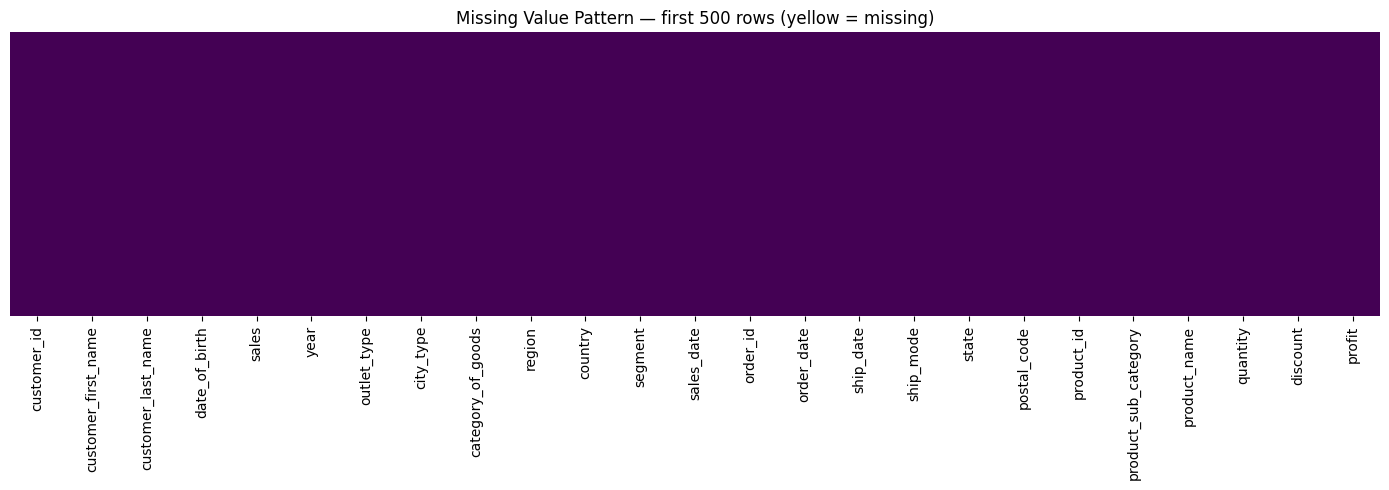

In [10]:
# Missing heatmap (first 500 rows for speed) 
plt.figure(figsize=(14, 5))
sns.heatmap(
    df.head(500).isnull(),
    cbar=False, yticklabels=False, cmap='viridis'
)
plt.title('Missing Value Pattern — first 500 rows (yellow = missing)')
plt.tight_layout()
plt.show()

In [11]:
# Exact duplicate rows 
n_dup = df.duplicated().sum()
print(f"Exact duplicate rows : {n_dup:,}  ({n_dup/len(df)*100:.2f}%)")

if n_dup > 0:
    print("\nSample duplicate rows (all occurrences):")
    display(df[df.duplicated(keep=False)].head(10))

Exact duplicate rows : 0  (0.00%)


In [12]:
import sweetviz as sv

report =sv.analyze(df)
report.show_html("report.html")

                                             |          | [  0%]   00:00 -> (? left)

Report report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [13]:
df['state'].value_counts()

state
Rajasthan         10240
Punjab            10154
Madhya Pradesh    10020
Maharashtra       10001
Delhi              9985
Tamil Nadu         9971
Gujarat            9953
Karnataka          9916
Uttar Pradesh      9908
West Bengal        9852
Name: count, dtype: int64

In [14]:
df['region'].value_counts()

region
East     25117
North    25043
South    25031
West     24809
Name: count, dtype: int64

In [15]:
region_mapping = {
    'Karnataka': 'South',
    'Tamil Nadu': 'South',

    'Delhi': 'North',
    'Punjab': 'North',
    'Uttar Pradesh': 'North',

    'West Bengal': 'East',

    'Gujarat': 'West',
    'Rajasthan': 'West',
    'Maharashtra': 'West',
    'Madhya Pradesh': 'West'
}

df['region'] = df['state'].map(region_mapping)



In [16]:
df['region'] = df['state'].map(region_mapping).fillna('Unknown')

In [17]:
df_subset = df[['state', 'region']]
df_subset.value_counts()

state           region
Rajasthan       West      10240
Punjab          North     10154
Madhya Pradesh  West      10020
Maharashtra     West      10001
Delhi           North      9985
Tamil Nadu      South      9971
Gujarat         West       9953
Karnataka       South      9916
Uttar Pradesh   North      9908
West Bengal     East       9852
Name: count, dtype: int64

In [18]:
df = df.drop(columns=["year", "sales_date"])

In [19]:
df['order_date'].min()

'2019-01-01'

In [20]:
df['order_date'].max()

'2023-12-31'


i am selecting order date as the date for making dashboard.

how do we add a is returned flag and on what basis?

why do we need to separate csv(s)? how do they differ?





In [21]:
# Synthetic 'Is Returned' flag — category-weighted, seeded.
#    No real return data exists, so we model it: durable goods get
#    returned more than perishables. Overall rate ~5-6%.
# ------------------------------------------------------------------
RETURN_PROB = {
    "Fast Food": 0.02,
    "Dairy Products": 0.03,
    "Sessional Fruits & Vegetables": 0.04,
    "Household Items": 0.05,
    "Furniture": 0.09,
    "Electric Appliances": 0.11,
}
 
np.random.seed(42)  # reproducible
probs = df["category_of_goods"].map(RETURN_PROB).fillna(0.05)
df["is_returned"] = (np.random.random(len(df)) < probs).astype(int)  # 1 = returned, 0 = not

In [22]:
df["is_returned"].value_counts()

is_returned
0    94299
1     5701
Name: count, dtype: int64

In [23]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date']  = pd.to_datetime(df['ship_date'])

In [24]:
df.columns

Index(['customer_id', 'customer_first_name', 'customer_last_name',
       'date_of_birth', 'sales', 'outlet_type', 'city_type',
       'category_of_goods', 'region', 'country', 'segment', 'order_id',
       'order_date', 'ship_date', 'ship_mode', 'state', 'postal_code',
       'product_id', 'product_sub_category', 'product_name', 'quantity',
       'discount', 'profit', 'is_returned'],
      dtype='str')

In [25]:
df.to_csv("fact_sales.csv", index=False)

print("Saved fact_sales.csv —", df.shape)
print(df.columns.tolist())

Saved fact_sales.csv — (100000, 24)
['customer_id', 'customer_first_name', 'customer_last_name', 'date_of_birth', 'sales', 'outlet_type', 'city_type', 'category_of_goods', 'region', 'country', 'segment', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'state', 'postal_code', 'product_id', 'product_sub_category', 'product_name', 'quantity', 'discount', 'profit', 'is_returned']


In [26]:
# --- targets.csv ---
tmp = df.copy()
tmp['month_start'] = tmp['order_date'].values.astype('datetime64[M]')

actuals = (tmp.groupby(['region', 'month_start'])['sales']
             .sum().reset_index().rename(columns={'sales': 'actual_revenue'}))

np.random.seed(42)
factors = np.random.uniform(0.90, 1.15, size=len(actuals))
actuals['target_revenue'] = (actuals['actual_revenue'] * factors).round(2)

targets = actuals[['region', 'month_start', 'target_revenue']]
targets.to_csv("targets.csv", index=False)
print("Saved targets.csv —", targets.shape)

Saved targets.csv — (240, 3)
